In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
import numpy as np
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt
from sklearn import metrics
from numpy import float32 
import time
from sklearn.metrics import confusion_matrix
import seaborn as sns
from sklearn.metrics import silhouette_score, calinski_harabasz_score

In [2]:
data=pd.read_csv("C:/Users/86183/BS/BS/denoised_spectra.csv")

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

In [4]:
# 2. 数据预处理
scaler = StandardScaler()
X_scaled = scaler.fit_transform(data)

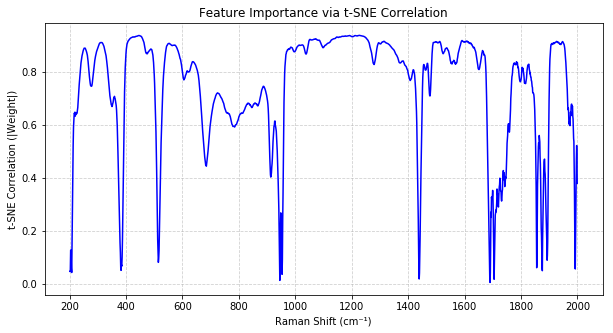

In [7]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.manifold import TSNE

# 1. 读取数据
header = pd.read_csv("C:/Users/86183/BS/BS/transposed_loss_output.csv", nrows=0).columns.tolist()
x_labels = np.array(header, dtype=float)
# df = pd.read_csv("C:/Users/86183/BS/BS/transposed_loss_output.csv", header=0)

# 2. 标准化数据
scaler = StandardScaler()
scaled_data = scaler.fit_transform(data)

# 3. t-SNE降维
tsne = TSNE(n_components=2, random_state=42, perplexity=20)  # 通常使用2D可视化
embedding = tsne.fit_transform(scaled_data)

# 4. 计算特征重要性（替代载荷）
# 方法：通过特征与t-SNE嵌入的相关性
feature_importance = np.array([
    np.corrcoef(scaled_data[:, i], embedding[:, 0])[0, 1]  # 与第一t-SNE维度的相关系数
    for i in range(scaled_data.shape[1])
])

# 5. 可视化
plt.figure(figsize=(10, 5))
plt.plot(x_labels, np.abs(feature_importance), color='blue', linewidth=1.5)  # 取绝对值
plt.title("Feature Importance via t-SNE Correlation")
plt.xlabel("Raman Shift (cm⁻¹)")
plt.ylabel("t-SNE Correlation (|Weight|)")
plt.xticks([200,400,600,800, 1000, 1200, 1400, 1600,1800,2000])
plt.grid(linestyle='--', alpha=0.6)
plt.show()


图片已保存至: t-SNE_variable.jpg


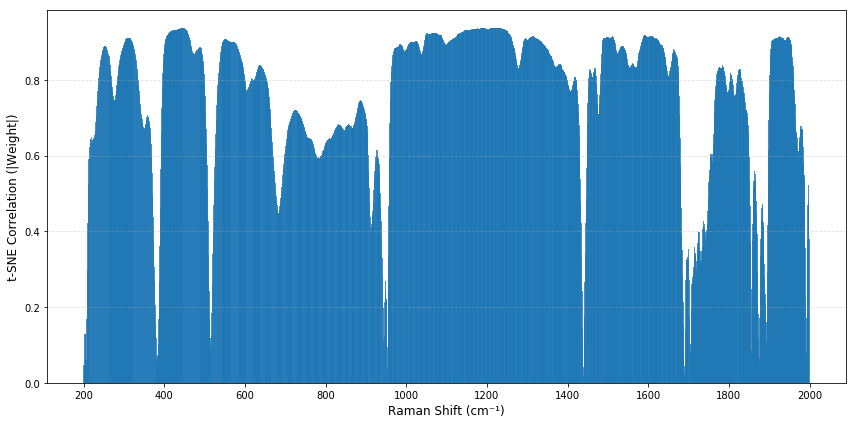

In [22]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.manifold import TSNE

# 1. 读取数据
header = pd.read_csv("C:/Users/86183/BS/BS/transposed_loss_output.csv", nrows=0).columns.tolist()
x_labels = np.array(header, dtype=float)
# df = pd.read_csv("C:/Users/86183/BS/BS/transposed_loss_output.csv", header=0)

# 2. 标准化数据
scaler = StandardScaler()
scaled_data = scaler.fit_transform(data)  # 确保data变量已正确定义

# 3. t-SNE降维
tsne = TSNE(n_components=2, random_state=42, perplexity=20)
embedding = tsne.fit_transform(scaled_data)

# 4. 计算特征重要性（绝对值）
feature_importance = np.array([
    np.abs(np.corrcoef(scaled_data[:, i], embedding[:, 0])[0, 1])
    for i in range(scaled_data.shape[1])
])

# 5. 纯净柱状图（无标记版）
plt.figure(figsize=(12, 6))

# 绘制柱状图（移除了所有text标注）
plt.bar(x_labels, feature_importance, 
        width=3.0,
       
        linewidth=0.5,
        alpha=0.8)

# 图表格式化
#plt.title("Feature Importance via t-SNE Correlation", fontsize=14)
plt.xlabel("Raman Shift (cm⁻¹)", fontsize=12)
plt.ylabel("t-SNE Correlation (|Weight|)", fontsize=12)
plt.xticks(np.arange(200, 2200, 200))  # 固定刻度间隔
plt.grid(axis='y', linestyle='--', alpha=0.4)  # 仅显示横向网格线
plt.tight_layout()
plt.savefig('tsne_feature_importance_clean.png', dpi=300, bbox_inches='tight')
save_path="t-SNE_variable.jpg"
plt.savefig(save_path, dpi=600, bbox_inches='tight')
print(f"图片已保存至: {save_path}")
plt.show()

#保存图片


图片已保存至: t-SNE_variable.jpg


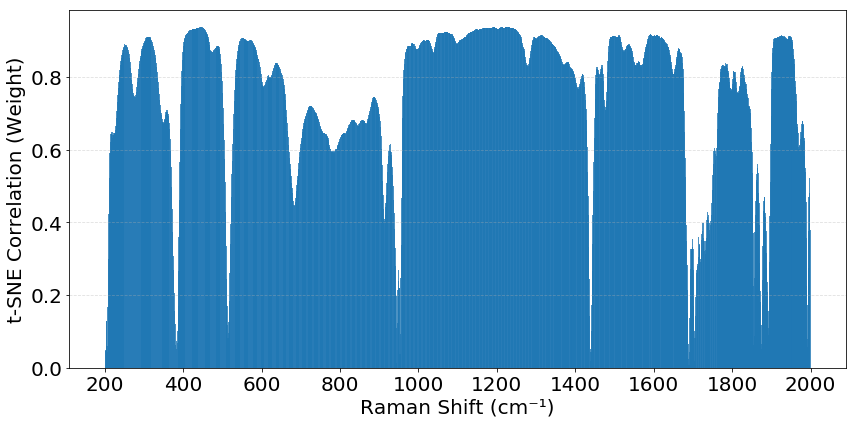

In [6]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.manifold import TSNE

# 1. 读取数据（注意：data变量需要正确定义）
header = pd.read_csv("C:/Users/86183/BS/BS/transposed_loss_output.csv", nrows=0).columns.tolist()
x_labels = np.array(header, dtype=float)
# df = pd.read_csv("C:/Users/86183/BS/BS/transposed_loss_output.csv", header=0)  # 需要取消注释并定义data

# 2. 标准化数据
scaler = StandardScaler()
scaled_data = scaler.fit_transform(data)  # 确保data变量已正确定义

# 3. t-SNE降维
tsne = TSNE(n_components=2, random_state=42, perplexity=20)
embedding = tsne.fit_transform(scaled_data)

# 4. 计算特征重要性（绝对值）
feature_importance = np.array([
    np.abs(np.corrcoef(scaled_data[:, i], embedding[:, 0])[0, 1])
    for i in range(scaled_data.shape[1])
])

# 5. 纯净柱状图（无标记版）
plt.figure(figsize=(12, 6))

# 绘制柱状图（移除了所有text标注）
plt.bar(x_labels, feature_importance, 
        width=3.0,
        linewidth=0.5,
        alpha=0.8)

# ============== 字号修改部分 ==============
# 坐标轴标签
plt.xlabel("Raman Shift (cm⁻¹)", fontsize=20)    # 原12改为20
plt.ylabel("t-SNE Correlation (Weight)", fontsize=20)  # 原12改为20

# 刻度标签
plt.xticks(np.arange(200, 2200, 200), fontsize=20)  # 添加字号设置
plt.yticks(fontsize=20)  # 添加y轴字号设置

# 网格线设置（保持原样）
plt.grid(axis='y', linestyle='--', alpha=0.4)
# ========================================

plt.tight_layout()

# 保存图片
save_path = "t-SNE_variable.jpg"
plt.savefig(save_path, dpi=600, bbox_inches='tight')
print(f"图片已保存至: {save_path}")
plt.show()


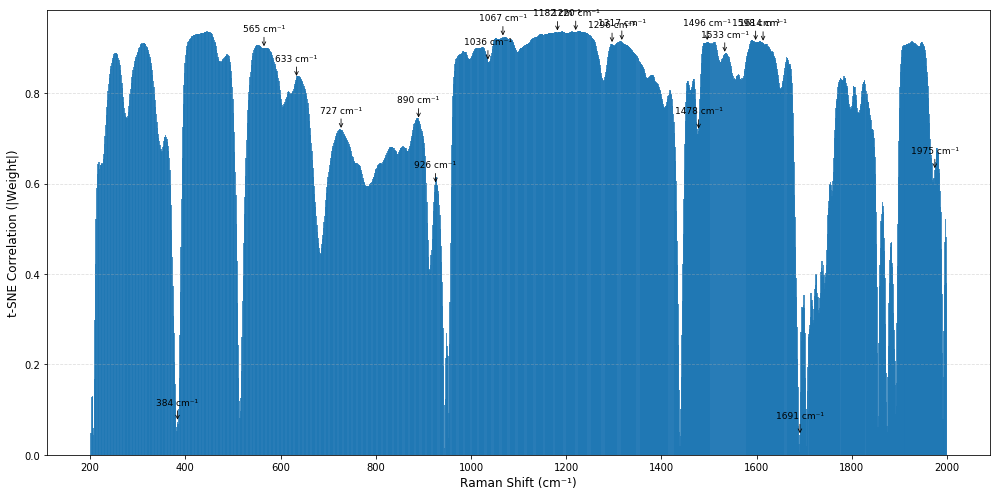

In [18]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.manifold import TSNE

# 1. 读取数据
header = pd.read_csv("C:/Users/86183/BS/BS/transposed_loss_output.csv", nrows=0).columns.tolist()
x_labels = np.array(header, dtype=float)
# df = pd.read_csv("C:/Users/86183/BS/BS/transposed_loss_output.csv", header=0)

# 2. 标准化数据
scaler = StandardScaler()
scaled_data = scaler.fit_transform(data)  # 确保data变量已正确定义

# 3. t-SNE降维
tsne = TSNE(n_components=2, random_state=42, perplexity=20)
embedding = tsne.fit_transform(scaled_data)

# 4. 计算特征重要性（绝对值）
feature_importance = np.array([
    np.abs(np.corrcoef(scaled_data[:, i], embedding[:, 0])[0, 1])
    for i in range(scaled_data.shape[1])
])

# 5. 指定要标注的波峰位置
peaks_to_label = [384, 565, 633, 727, 890, 926, 1036, 1067, 1182, 
                  1220, 1296, 1317, 1478, 1496, 1533, 1598, 1614, 
                  1691, 1975]

# 6. 绘制柱状图并标注指定波峰
plt.figure(figsize=(14, 7))

# 绘制柱状图
bars = plt.bar(x_labels, feature_importance, 
               width=3.0,
               linewidth=0.5,
               alpha=0.8)

# 找到最接近指定波峰的索引
def find_nearest(array, value):
    array = np.asarray(array)
    idx = (np.abs(array - value)).argmin()
    return idx

# 标注每个指定的波峰
for peak in peaks_to_label:
    idx = find_nearest(x_labels, peak)
    if 0 <= idx < len(x_labels):  # 确保索引有效
        plt.annotate(f"{x_labels[idx]:.0f} cm⁻¹", 
                    (x_labels[idx], feature_importance[idx]),
                    xytext=(0, 15), 
                    textcoords="offset points",
                    ha='center', va='bottom',
                    fontsize=9,
                    arrowprops=dict(arrowstyle="->", 
                                   color='black',
                                   linewidth=0.8))

# 图表格式化
plt.xlabel("Raman Shift (cm⁻¹)", fontsize=12)
plt.ylabel("t-SNE Correlation (|Weight|)", fontsize=12)
plt.xticks(np.arange(200, 2200, 200))  # 固定刻度间隔
plt.grid(axis='y', linestyle='--', alpha=0.4)  # 仅显示横向网格线

plt.tight_layout()
plt.savefig('tsne_feature_importance_with_specified_peaks.png', dpi=300, bbox_inches='tight')
plt.show()


In [5]:
tsne = TSNE( perplexity=30)
X_tsne = tsne.fit_transform(X_scaled)

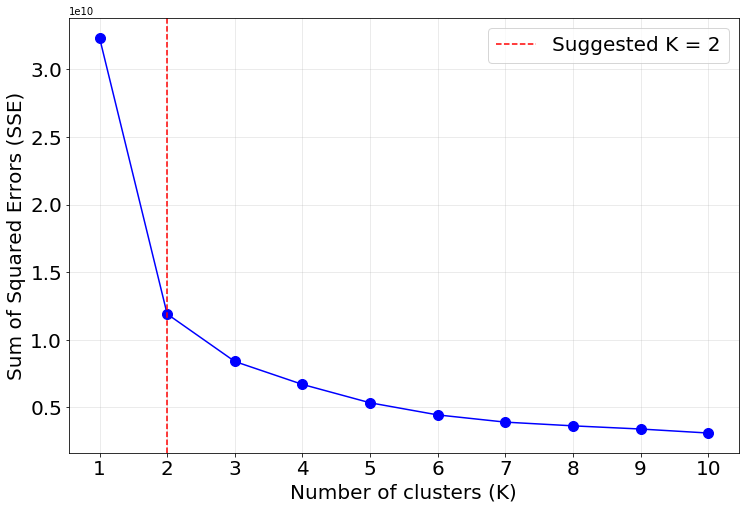

Suggested optimal K (elbow point): 2


In [19]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.datasets import make_blobs
from sklearn.preprocessing import StandardScaler

# # 1. 生成模拟数据（或替换为你的实际数据）
# X, y = make_blobs(n_samples=1000, centers=5, n_features=2, random_state=42)
# X = StandardScaler().fit_transform(X)  # 标准化数据

# 2. 定义K值测试范围
k_range = range(1, 11)  # 通常测试1-10个聚类
sse = []  # 存储每个K对应的SSE（误差平方和）

# 3. 计算不同K值的SSE
for k in k_range:
    kmeans = KMeans(n_clusters=k, init='k-means++', random_state=42)
    kmeans.fit(data)
    sse.append(kmeans.inertia_)  # inertia_即SSE

# 4. 绘制肘部曲线
plt.figure(figsize=(12,8))
plt.plot(k_range, sse, 'bo-', markersize=10)
plt.xticks(k_range)
plt.xticks(k_range, fontsize=20)
plt.yticks(fontsize=20)
plt.xlabel('Number of clusters (K)', fontsize=20)
plt.ylabel('Sum of Squared Errors (SSE)', fontsize=20)
# plt.title('Elbow Method for Optimal K', fontsize=20)

# 5. 标记可能的肘点（自动检测示例）
deltas = np.diff(sse) / sse[1:]  # 计算二阶导数变化率
elbow_k = np.argmin(deltas) + 2  # +2补偿索引偏移
plt.axvline(x=elbow_k, color='r', linestyle='--', 
            label=f'Suggested K = {elbow_k}')
# 5. 图例和网格（字号适配）
plt.legend(fontsize=20, framealpha=0.8)
plt.grid(True, alpha=0.3)
plt.tick_params(axis='both', which='major', labelsize=20)  # 坐标轴刻度字号
plt.show()

# 6. 输出建议K值
print(f"Suggested optimal K (elbow point): {elbow_k}")


聚类标签： [0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 1 1 1 1 1 1 0 0 0 1 0 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 0 0 1 1 1 1 1 1 1 1 0 1 0 1 1 1 1 1 0 1 1 0 0 1 1 1 1
 0 0 1 1 1 0 1 0 0 0 0 0 1 0 1 1 0 1 1 0 1 0 0 1 0 0 1 1 0 1 1 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 1 0 0 1 1 1 0 0 0 0 1 1 0 1 1 1 1 1 0 1 1
 1]
聚类中心： [[-2.4256084 -0.2802868]
 [ 9.995902  -5.36374  ]]


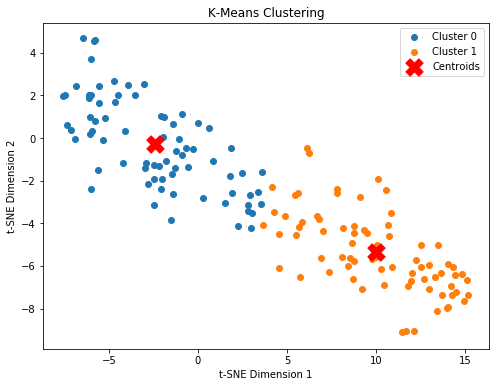

0.6147074
Calinski-Harabasz指数: 452.5587872012549


In [7]:
import numpy as np
import pandas as pd
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt


# 选择聚类的数量 k
# 这里我们假设 k=3，你可以根据实际情况调整
k = 2

# 创建 KMeans 模型
kmeans = KMeans(n_clusters=k)

# 拟合模型
kmeans.fit(X_tsne)

# 获取聚类结果
labels = kmeans.labels_  # 每个样本的聚类标签
centroids = kmeans.cluster_centers_  # 聚类中心

# 打印聚类结果
print("聚类标签：", labels)
print("聚类中心：", centroids)

 #设置3D坐标系的背景颜色为白色
# ax.set_facecolor('white')
# fig.patch.set_facecolor('white')
# plt.tight_layout()

plt.figure(figsize=(8, 6))
for i in range(k):
    plt.scatter(X_tsne[labels == i, 0], X_tsne[labels == i, 1], label=f'Cluster {i}')
plt.scatter(centroids[:, 0], centroids[:, 1], s=300, c='red', marker='X', label='Centroids')
plt.title("K-Means Clustering")
plt.xlabel("t-SNE Dimension 1")
plt.ylabel("t-SNE Dimension 2")

plt.legend()
plt.show()
from sklearn.metrics import silhouette_score
print(silhouette_score(X_tsne, kmeans.labels_))  # 值越接近1越好‌:ml-citation{ref="3,7" data="citationList"}
print("Calinski-Harabasz指数:", calinski_harabasz_score(X_tsne, kmeans.labels_))

In [43]:
# import pandas as pd
# # 转换为DataFrame并保存为CSV
# df = pd.DataFrame({'Label': labels})
# df.to_csv('labels_tsne_kmeans.csv', index=False)  # 不保存行索引‌:ml-citation{ref="2,4" data="citationList"}


图片已保存至: T-SNE_kmeans_clustering.jpg


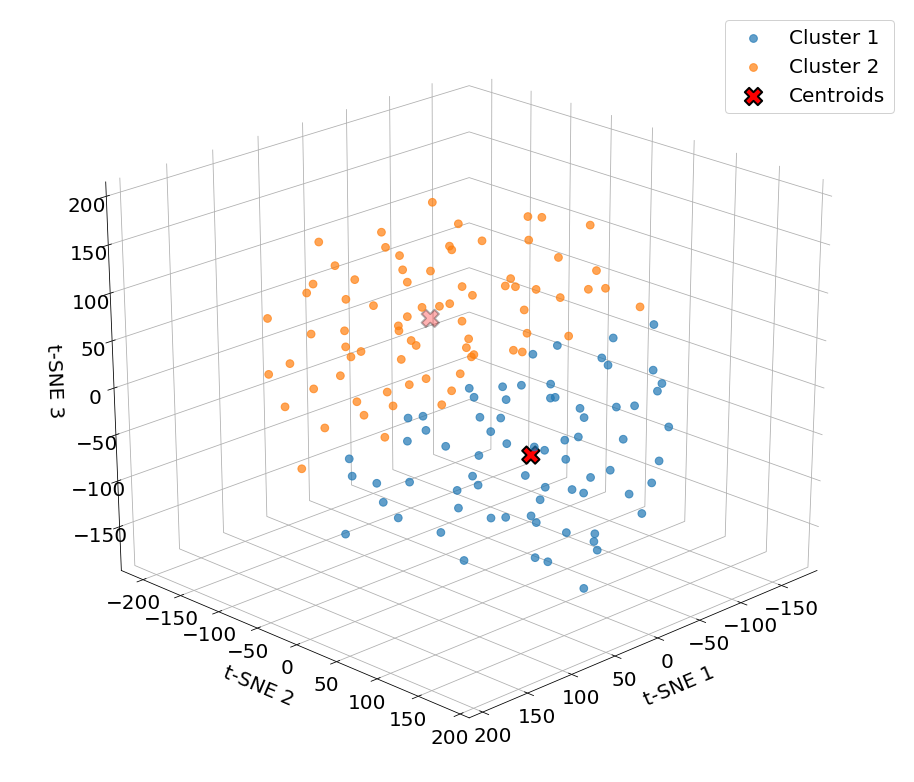

Silhouette Score: 0.2726
Calinski-Harabasz Index: 66.3271


In [19]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
from sklearn.cluster import KMeans
from mpl_toolkits.mplot3d import Axes3D
from sklearn.metrics import silhouette_score, calinski_harabasz_score

# Assuming X_scaled is your preprocessed data
tsne_3d = TSNE(n_components=3, perplexity=30, random_state=42)
X_tsne_3d = tsne_3d.fit_transform(X_scaled)

# K-Means clustering (k=2)
k = 2
kmeans = KMeans(n_clusters=k, random_state=42)
labels = kmeans.fit_predict(X_tsne_3d)
centroids = kmeans.cluster_centers_

# 3D visualization with larger fonts
fig = plt.figure(figsize=(16, 14))  # Increased figure size
ax = fig.add_subplot(111, projection='3d')

# Set global font sizes
plt.rcParams.update({
    'legend.fontsize': 20,
    'axes.labelsize': 20,
    'xtick.labelsize': 20,
    'ytick.labelsize': 20,
    'axes.titlesize': 20
})

# Plot each cluster
for i in range(k):
    ax.scatter(
        X_tsne_3d[labels == i, 0],
        X_tsne_3d[labels == i, 1],
        X_tsne_3d[labels == i, 2],
        label=f'Cluster {i+1}',  # Changed to 1-based indexing
        alpha=0.7,
        s=60  # Increased marker size
    )

# Plot centroids
ax.scatter(
    centroids[:, 0], centroids[:, 1], centroids[:, 2],
    s=300, c='red', label='Centroids',
    edgecolors='black', linewidths=2,
    marker='X'  # Changed to X marker
)

# Axis labels with fontsize 20
ax.set_xlabel('t-SNE 1', fontsize=20, labelpad=15)
ax.set_ylabel('t-SNE 2', fontsize=20, labelpad=15)
ax.set_zlabel('t-SNE 3', fontsize=20, labelpad=15)

# Legend with larger font
ax.legend(fontsize=20, framealpha=0.9)

# Adjust view angle
ax.view_init(elev=25, azim=45)

# Set background to white
ax.xaxis.set_pane_color((1.0, 1.0, 1.0, 1.0))
ax.yaxis.set_pane_color((1.0, 1.0, 1.0, 1.0))
ax.zaxis.set_pane_color((1.0, 1.0, 1.0, 1.0))

# Save high-quality image
save_path = "T-SNE_kmeans_clustering.jpg"
plt.savefig(save_path, dpi=600, bbox_inches='tight', facecolor='white')
print(f"图片已保存至: {save_path}")

plt.show()

# Evaluation metrics
print(f"Silhouette Score: {silhouette_score(X_tsne_3d, kmeans.labels_):.4f}")
print(f"Calinski-Harabasz Index: {calinski_harabasz_score(X_tsne_3d, kmeans.labels_):.4f}")


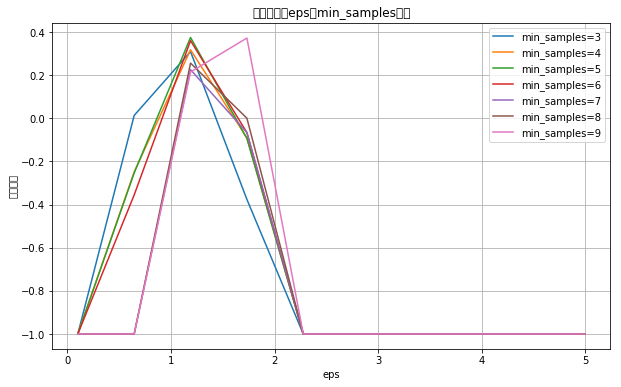

最佳eps: 1.188888888888889, 最佳min_samples: 5.0, 最佳轮廓系数: 0.37493693828582764


In [40]:
import numpy as np
from sklearn.cluster import DBSCAN
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

# 假设拉曼光谱数据已经预处理并存储在变量data中
# data = ...


# 定义eps和min_samples的范围
eps_range = np.linspace(0.1, 5, 10)
min_samples_range = range(3, 10)

# 存储每个eps和min_samples组合对应的轮廓系数
results = []

# 网格搜索
for eps in eps_range:
    for min_samples in min_samples_range:
        # DBSCAN聚类
        dbscan = DBSCAN(eps=eps, min_samples=min_samples)
        labels = dbscan.fit_predict(X_tsne)
        
        # 计算轮廓系数
        if len(set(labels)) > 1:
            score = silhouette_score(X_tsne, labels)
            results.append((eps, min_samples, score))
        else:
            results.append((eps, min_samples, -1))  # 如果只有一个簇，轮廓系数设为-1

# 转换为numpy数组以便于处理
results = np.array(results)

# 绘制轮廓系数随eps变化的图
plt.figure(figsize=(10, 6))
for min_samples in min_samples_range:
    # 筛选出特定min_samples对应的eps和轮廓系数
    filtered_results = results[results[:, 1] == min_samples]
    plt.plot(filtered_results[:, 0], filtered_results[:, 2], label=f'min_samples={min_samples}')

plt.xlabel('eps')
plt.ylabel('轮廓系数')
plt.title('轮廓系数随eps和min_samples变化')
plt.legend()
plt.grid(True)
plt.show()

# 找出最佳的eps和min_samples组合
best_index = np.argmax(results[:, 2])
best_eps, best_min_samples, best_score = results[best_index]
print(f'最佳eps: {best_eps}, 最佳min_samples: {best_min_samples}, 最佳轮廓系数: {best_score}')

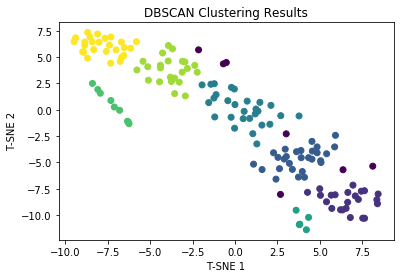

轮廓系数：0.4692
Calinski-Harabasz指数: 253.2119023410189


In [13]:
import numpy as np
from sklearn.cluster import DBSCAN
import matplotlib.pyplot as plt
from sklearn.metrics import silhouette_score

# 应用DBSCAN聚类
dbscan = DBSCAN(eps=1.188, min_samples=3)
clusters = dbscan.fit_predict(X_tsne)

# # 计算轮廓系数
# silhouette_avg = silhouette_score(X_tsne, clusters)
# print(f'平均轮廓系数: {silhouette_avg:.3f}')

# 可视化聚类结果
# 可视化聚类结果
plt.scatter(X_tsne[:, 0], X_tsne[:, 1], c=clusters, cmap='viridis', marker='o')
plt.title('DBSCAN Clustering Results')
plt.xlabel('T-SNE 1')
plt.ylabel('T-SNE 2')
plt.show()
from sklearn.metrics import silhouette_score
# X为数据集，labels为聚类结果
score = silhouette_score(X_tsne,clusters)
print('轮廓系数：%.4f' % score)
print("Calinski-Harabasz指数:", calinski_harabasz_score(X_tsne,clusters))

In [62]:
# labels = dbscan.labels_ 
# import pandas as pd
# # 转换为DataFrame并保存为CSV
# df = pd.DataFrame({'Label': labels})
# df.to_csv('labels_tsne_dbscan.csv', index=False)  # 不保存行索引‌:ml-citation{ref="2,4" data="citationList"}


In [118]:
clusters

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 1, 1,
       1, 1, 1, 1, 1, 0, 0, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 0, 1, 1, 1, 1, 1, 0,
       1, 1, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 1, 1, 0,
       1, 1, 0, 1, 1, 1, 1, 1, 0, 1, 1, 0, 1, 1, 0, 1, 1, 0, 0, 0, 0, 0,
       1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 1, 0, 1, 0, 0, 1, 1,
       1, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1], dtype=int64)

聚类标签： [1 1 1 1 1 1 1 1 1 1 1 0 1 0 0 1 1 1 1 1 0 0 0 0 0 0 0 1 1 0 1 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 1 1 0 0 0 0 0 0 0 0 1 0 1 0 0 0 0 0 1 0 0 1 1 0 0 0 0
 0 0 0 0 0 0 0 0 0 1 1 0 0 1 0 0 1 0 0 0 0 0 1 0 0 1 0 0 1 0 0 1 1 1 1 1 0
 1 1 1 1 1 1 1 1 1 1 0 0 1 1 0 1 0 1 1 0 0 0 1 1 1 1 0 0 0 0 0 0 0 0 1 0 0
 0]


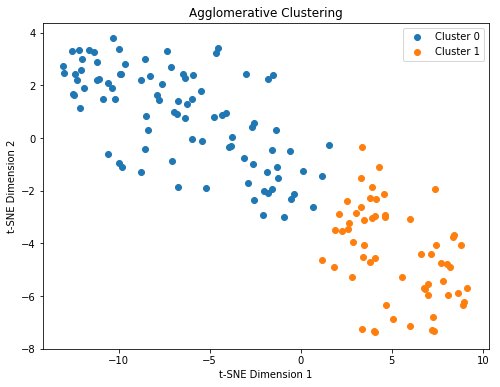

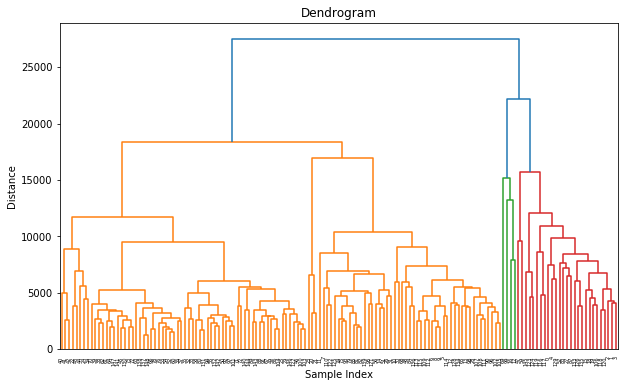

Silhouette Score: 0.594 (越接近1越好)
Calinski-Harabasz指数: 382.74908801006103


In [41]:
import numpy as np
import pandas as pd
from sklearn.cluster import AgglomerativeClustering
import matplotlib.pyplot as plt
from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.decomposition import PCA



# 选择聚类的数量
# 这里我们假设 k=3，你可以根据实际情况调整
k = 2

# 创建层次聚类模型
agglo = AgglomerativeClustering(n_clusters=k, linkage='average')

# 拟合模型
agglo.fit(X_tsne)

# 获取聚类结果
labels = agglo.labels_  # 每个样本的聚类标签

# 打印聚类结果
print("聚类标签：", labels)

# 可视化聚类结果（使用PCA降维到2维）
pca = PCA(n_components=2)
data_2d = pca.fit_transform(X_tsne)

plt.figure(figsize=(8, 6))
for i in range(k):
    plt.scatter(X_tsne[labels == i, 0], X_tsne[labels == i, 1], label=f'Cluster {i}')
plt.title("Agglomerative Clustering")
plt.xlabel("t-SNE Dimension 1")
plt.ylabel("t-SNE Dimension 2")
plt.legend()
plt.show()

# 绘制层次聚类的树状图（Dendrogram）
plt.figure(figsize=(10, 6))
dendrogram(linkage(data, method='average'))
plt.title("Dendrogram")
plt.xlabel("Sample Index")
plt.ylabel("Distance")
plt.show()
silhouette_avg = silhouette_score(X_tsne, labels)
print(f"Silhouette Score: {silhouette_avg:.3f} (越接近1越好)")
print("Calinski-Harabasz指数:", calinski_harabasz_score(X_tsne, labels))

In [144]:

import pandas as pd
# 转换为DataFrame并保存为CSV
df = pd.DataFrame({'Label': labels})
df.to_csv('labels_tsne_Cengcluster.csv', index=False)  # 不保存行索引‌:ml-citation{ref="2,4" data="citationList"}


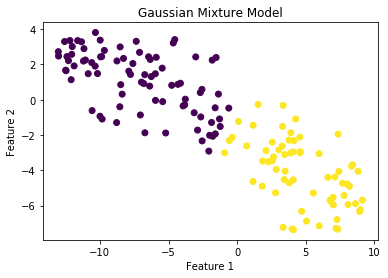

Silhouette Score: 0.611 (越接近1越好)
Calinski-Harabasz指数: 435.78992198613776


In [42]:
import numpy as np
from sklearn.mixture import GaussianMixture
import matplotlib.pyplot as plt

# 生成一些数据

# 创建并拟合GMM模型
gmm = GaussianMixture(n_components=2, covariance_type='full')
gmm.fit(X_tsne)

# 预测每个样本的类别
labels = gmm.predict(X_tsne)

# 绘制结果
plt.scatter(X_tsne[:, 0], X_tsne[:, 1], c=labels, cmap='viridis', marker='o')
plt.title('Gaussian Mixture Model')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.show()
silhouette_avg = silhouette_score(X_tsne, labels)
print(f"Silhouette Score: {silhouette_avg:.3f} (越接近1越好)")
print("Calinski-Harabasz指数:", calinski_harabasz_score(X_tsne, labels))



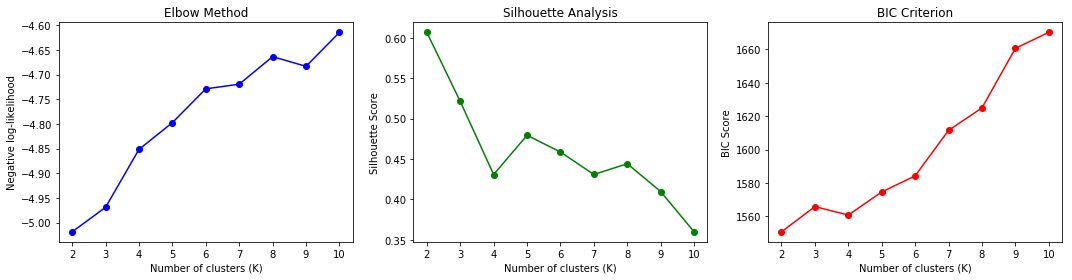

Best K based on BIC: 2


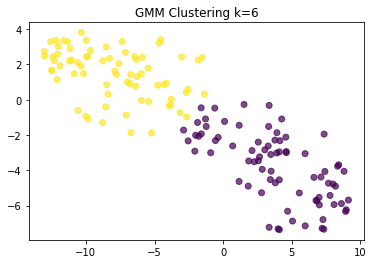

Silhouette Score: 0.607 (越接近1越好)
Calinski-Harabasz指数: 435.29090977312984


In [43]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.mixture import GaussianMixture
from sklearn.datasets import make_blobs
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler


# 定义K值搜索范围
K_range = range(2, 11)

# 方法1：肘部法则（基于inertia_）
inertias = []
for k in K_range:
    gmm = GaussianMixture(n_components=k, random_state=42)
    gmm.fit(X_tsne)
    inertias.append(gmm.lower_bound_)  # 负对数似然（越小越好）

plt.figure(figsize=(15, 4))
plt.subplot(131)
plt.plot(K_range, inertias, 'bo-')
plt.xlabel('Number of clusters (K)')
plt.ylabel('Negative log-likelihood')
plt.title('Elbow Method')

# 方法2：轮廓系数
silhouette_scores = []
for k in K_range:
    gmm = GaussianMixture(n_components=k, random_state=42)
    labels = gmm.fit_predict(X_tsne)
    if len(np.unique(labels)) < 2:  # 至少需要2个聚类才能计算
        silhouette_scores.append(-1)
    else:
        silhouette_scores.append(silhouette_score(X_tsne, labels))

plt.subplot(132)
plt.plot(K_range, silhouette_scores, 'go-')
plt.xlabel('Number of clusters (K)')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Analysis')

# 方法3：BIC准则（越小越好）
bic_scores = []
for k in K_range:
    gmm = GaussianMixture(n_components=k, random_state=42)
    gmm.fit(X_tsne)
    bic_scores.append(gmm.bic(X_tsne))

plt.subplot(133)
plt.plot(K_range, bic_scores, 'ro-')
plt.xlabel('Number of clusters (K)')
plt.ylabel('BIC Score')
plt.title('BIC Criterion')

plt.tight_layout()
plt.show()

# 自动选择最佳K值（以BIC为例）
best_k = K_range[np.argmin(bic_scores)]
print(f"Best K based on BIC: {best_k}")

# 用最佳K值训练最终模型
best_gmm = GaussianMixture(n_components=2, random_state=42)
best_gmm.fit(X_tsne)
labels = best_gmm.predict(X_tsne)

# 可视化聚类结果
plt.scatter(X_tsne[:, 0],X_tsne[:, 1], c=labels, cmap='viridis', alpha=0.7)
plt.title(f'GMM Clustering k=6')
plt.show()
silhouette_avg = silhouette_score(X_tsne, labels)
print(f"Silhouette Score: {silhouette_avg:.3f} (越接近1越好)")
print("Calinski-Harabasz指数:", calinski_harabasz_score(X_tsne, labels))

In [140]:

import pandas as pd
# 转换为DataFrame并保存为CSV
df = pd.DataFrame({'Label': labels})
df.to_csv('labels_tsne_GMM.csv', index=False)  # 不保存行索引‌:ml-citation{ref="2,4" data="citationList"}


轮廓系数: 0.5935241
Calinski-Harabasz指数: 382.74908801006103


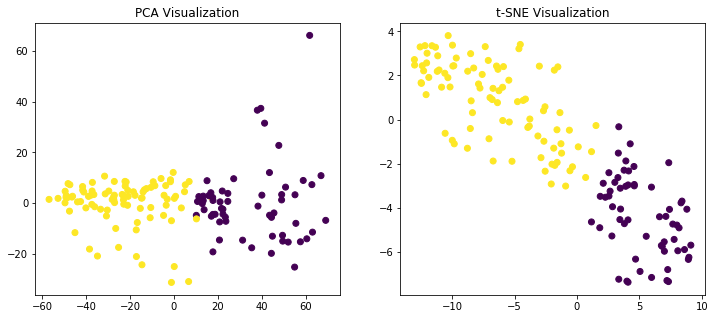

In [44]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import SpectralClustering
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score, calinski_harabasz_score
from sklearn.manifold import TSNE
# ----------------------
# 谱聚类
# ----------------------
n_clusters = 2 # 根据实际情况调整（可通过肘部法则确定）

model = SpectralClustering(
    n_clusters=n_clusters,
    affinity='rbf',          # 高斯核函数
    gamma=1,               # 核参数，需优化
    assign_labels='kmeans',  # 对特征向量进行kmeans
    random_state=42
)

labels = model.fit_predict(X_tsne)

# ----------------------
# 评估与可视化
# ----------------------
# 1. 评估指标（无监督）
print("轮廓系数:", silhouette_score(X_tsne, labels))
print("Calinski-Harabasz指数:", calinski_harabasz_score(X_tsne, labels))

# 2. 可视化（使用PCA/t-SNE）
plt.figure(figsize=(12, 5))

# PCA 2D投影
plt.subplot(121)
pca_vis = PCA(n_components=2)
X_pca_vis = pca_vis.fit_transform(X_scaled)
plt.scatter(X_pca_vis[:, 0], X_pca_vis[:, 1], c=labels, cmap='viridis')
plt.title("PCA Visualization")

# t-SNE 2D投影
plt.subplot(122)
tsne = TSNE(n_components=2, perplexity=30, random_state=42)
X_tsne = tsne.fit_transform(X_scaled)
plt.scatter(X_tsne[:, 0], X_tsne[:, 1], c=labels, cmap='viridis')
plt.title("t-SNE Visualization")

plt.show()


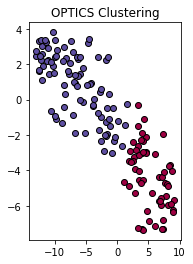

In [31]:
# 聚类结果
plt.subplot(122)
unique_labels = set(labels)
colors = [plt.cm.Spectral(each) for each in np.linspace(0, 1, len(unique_labels))]
for k, col in zip(unique_labels, colors):
    if k == -1:
        col = (0, 0, 0, 1)  # 黑色表示噪声
    class_member_mask = (labels == k)
    xy = X_tsne[class_member_mask]
    plt.plot(xy[:, 0], xy[:, 1], 'o', markerfacecolor=tuple(col),
             markeredgecolor='k', markersize=6)
plt.title('OPTICS Clustering')
plt.show()